# 06 - Machine Learning

Este notebook aplica Machine Learning ao projeto **Agro Leads Orchestrator**.

O objetivo é criar um modelo de classificação para estimar a probabilidade de uma interação comercial resultar em venda.

A base utilizada vem da simulação operacional gerada no Notebook 05.

## Objetivos da etapa

Nesta etapa serão aplicados conceitos de Ciência de Dados e Machine Learning:

- criação da variável alvo;
- preparação da base de modelagem;
- separação entre treino e teste;
- pré-processamento de variáveis categóricas e numéricas;
- treinamento de modelos de classificação;
- avaliação com métricas;
- matriz de confusão;
- análise de importância das variáveis;
- geração de arquivos de saída para documentação do projeto.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
#Raiz do projeto

RAIZ_PROJETO = Path.cwd()

if RAIZ_PROJETO.name == "notebooks":
    RAIZ_PROJETO = RAIZ_PROJETO.parent

if str(RAIZ_PROJETO) not in sys.path:
    sys.path.append(str(RAIZ_PROJETO))

print("Raiz do projeto:", RAIZ_PROJETO)

Raiz do projeto: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator


In [3]:
#Importar funções internas

from src.modelagem import (
    criar_base_modelagem,
    separar_variaveis,
    criar_pipeline_regressao_logistica,
    criar_pipeline_random_forest,
    avaliar_modelo,
    obter_matriz_confusao,
    obter_relatorio_classificacao,
    obter_importancia_variaveis_random_forest
)

In [4]:
#Definir caminhos

CAMINHO_OUTPUTS = RAIZ_PROJETO / "outputs"
CAMINHO_GRAFICOS = CAMINHO_OUTPUTS / "graficos"

CAMINHO_LOGS_SIMULACAO = CAMINHO_OUTPUTS / "logs_simulacao_operacao.csv"

CAMINHO_OUTPUTS.mkdir(parents=True, exist_ok=True)
CAMINHO_GRAFICOS.mkdir(parents=True, exist_ok=True)

print("Arquivo de logs:", CAMINHO_LOGS_SIMULACAO)
print("Arquivo existe?", CAMINHO_LOGS_SIMULACAO.exists())

Arquivo de logs: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator\outputs\logs_simulacao_operacao.csv
Arquivo existe? True


In [5]:
#Carregar logs da simulação

logs_simulacao = pd.read_csv(CAMINHO_LOGS_SIMULACAO)

logs_simulacao.head()

,cenario,numero_interacao,data_interacao,id_cliente,canal,resultado,cultura,estagio_atual,status_antes,status_depois,score_prioridade,score_antes
0,Sem Orquestrador,1,2026-07-01 21:08:53,483225,Robô,Atendido com Transferência,Milho,Entresafra,Disponível,Disponível,49.88,NaN
1,Sem Orquestrador,2,2026-07-01 21:08:53,266295,Humano,Não Atendido,Soja,Entresafra,Em Atendimento,Em Atendimento,19.95,NaN
2,Sem Orquestrador,3,2026-07-01 21:08:53,926056,Humano,Atendido sem Venda,Milho,Safra,Disponível,Disponível,71.82,NaN
3,Sem Orquestrador,4,2026-07-01 21:08:53,936997,Robô,Não Atendido,Soja,Entresafra,Em Atendimento,Em Atendimento,20.37,NaN
4,Sem Orquestrador,5,2026-07-01 21:08:53,530665,Humano,Venda,Soja,Desenvolvimento,Disponível,Disponível,65.00,NaN


In [6]:
#Verificar dimensão dos logs

print(f"Total de linhas: {len(logs_simulacao):,}")
print(f"Total de colunas: {logs_simulacao.shape[1]}")

Total de linhas: 600
Total de colunas: 12


In [7]:
#Verificar resultados disponíveis

logs_simulacao["resultado"].value_counts()

resultado
Não Atendido                  364
Atendido com Transferência     94
Resposta WhatsApp              61
Atendido sem Venda             51
Venda                          30
Name: count, dtype: int64

In [8]:
#Criar base de modelagem

dados_modelagem = criar_base_modelagem(logs_simulacao)

dados_modelagem.head()

,cenario,canal,cultura,estagio_atual,status_antes,score_prioridade,converteu
0,Sem Orquestrador,Robô,Milho,Entresafra,Disponível,49.88,0
1,Sem Orquestrador,Humano,Soja,Entresafra,Em Atendimento,19.95,0
2,Sem Orquestrador,Humano,Milho,Safra,Disponível,71.82,0
3,Sem Orquestrador,Robô,Soja,Entresafra,Em Atendimento,20.37,0
4,Sem Orquestrador,Humano,Soja,Desenvolvimento,Disponível,65.00,1


In [9]:
#Verificar variável alvo

distribuicao_alvo = (
    dados_modelagem["converteu"]
    .value_counts()
    .rename_axis("converteu")
    .reset_index(name="quantidade")
)

distribuicao_alvo["percentual"] = (
    distribuicao_alvo["quantidade"]
    / distribuicao_alvo["quantidade"].sum()
    * 100
)

distribuicao_alvo

,converteu,quantidade,percentual
0,0,570,95.0
1,1,30,5.0


## Variável alvo

A variável `converteu` representa se uma interação comercial resultou em venda.

- `1`: interação com resultado Venda;
- `0`: demais interações.

Como vendas são naturalmente menos frequentes que não vendas, é esperado existir desbalanceamento entre as classes.

In [10]:
#Separar variáveis explicativas e alvo

x, y = separar_variaveis(dados_modelagem)

x.head()

,cenario,canal,cultura,estagio_atual,status_antes,score_prioridade
0,Sem Orquestrador,Robô,Milho,Entresafra,Disponível,49.88
1,Sem Orquestrador,Humano,Soja,Entresafra,Em Atendimento,19.95
2,Sem Orquestrador,Humano,Milho,Safra,Disponível,71.82
3,Sem Orquestrador,Robô,Soja,Entresafra,Em Atendimento,20.37
4,Sem Orquestrador,Humano,Soja,Desenvolvimento,Disponível,65.00


In [11]:
#Separar treino e teste

x_treino, x_teste, y_treino, y_teste = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Treino: {len(x_treino):,} registros")
print(f"Teste: {len(x_teste):,} registros")

Treino: 450 registros
Teste: 150 registros


In [12]:
#Criar modelo de Regressão Logística

modelo_regressao_logistica = criar_pipeline_regressao_logistica()

modelo_regressao_logistica

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categoricas', ...), ('numericas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

In [13]:
#Treinar Regressão Logística

modelo_regressao_logistica.fit(
    x_treino,
    y_treino
)

print("Modelo de Regressão Logística treinado com sucesso.")

Modelo de Regressão Logística treinado com sucesso.


In [14]:
#Avaliar Regressão Logística

metricas_regressao = avaliar_modelo(
    modelo=modelo_regressao_logistica,
    x_teste=x_teste,
    y_teste=y_teste,
    nome_modelo="Regressão Logística"
)

metricas_regressao

{'modelo': 'Regressão Logística',
 'acuracia': 0.6933333333333334,
 'precisao': 0.11764705882352941,
 'recall': 0.8571428571428571,
 'f1_score': 0.20689655172413793,
 'roc_auc': 0.8361638361638362}

In [15]:
#Matriz de confusão da Regressão Logística

matriz_regressao = obter_matriz_confusao(
    modelo=modelo_regressao_logistica,
    x_teste=x_teste,
    y_teste=y_teste
)

matriz_regressao

,Previsto Não Venda,Previsto Venda
Real Não Venda,98,45
Real Venda,1,6


In [16]:
#Relatório de classificação da Regressão Logística

relatorio_regressao = obter_relatorio_classificacao(
    modelo=modelo_regressao_logistica,
    x_teste=x_teste,
    y_teste=y_teste
)

relatorio_regressao.round(3)

,precision,recall,f1-score,support
0,0.990,0.685,0.810,143.000
1,0.118,0.857,0.207,7.000
accuracy,0.693,0.693,0.693,0.693
macro avg,0.554,0.771,0.508,150.000
weighted avg,0.949,0.693,0.782,150.000


In [17]:
#Criar modelo Random Forest

modelo_random_forest = criar_pipeline_random_forest()

modelo_random_forest

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categoricas', ...), ('numericas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

In [18]:
#Treinar Random Forest

modelo_random_forest.fit(
    x_treino,
    y_treino
)

print("Modelo Random Forest treinado com sucesso.")

Modelo Random Forest treinado com sucesso.


In [19]:
#Avaliar Random Forest

metricas_random_forest = avaliar_modelo(
    modelo=modelo_random_forest,
    x_teste=x_teste,
    y_teste=y_teste,
    nome_modelo="Random Forest"
)

metricas_random_forest

{'modelo': 'Random Forest',
 'acuracia': 0.8266666666666667,
 'precisao': 0.21212121212121213,
 'recall': 1.0,
 'f1_score': 0.35,
 'roc_auc': 0.9540459540459539}

In [20]:
#Matriz de confusão da Random Forest

matriz_random_forest = obter_matriz_confusao(
    modelo=modelo_random_forest,
    x_teste=x_teste,
    y_teste=y_teste
)

matriz_random_forest

,Previsto Não Venda,Previsto Venda
Real Não Venda,117,26
Real Venda,0,7


In [21]:
#Relatório de classificação da Random Forest

relatorio_random_forest = obter_relatorio_classificacao(
    modelo=modelo_random_forest,
    x_teste=x_teste,
    y_teste=y_teste
)

relatorio_random_forest.round(3)

,precision,recall,f1-score,support
0,1.000,0.818,0.900,143.000
1,0.212,1.000,0.350,7.000
accuracy,0.827,0.827,0.827,0.827
macro avg,0.606,0.909,0.625,150.000
weighted avg,0.963,0.827,0.874,150.000


In [22]:
#Consolidar métricas

comparativo_modelos = pd.DataFrame([
    metricas_regressao,
    metricas_random_forest
])

comparativo_modelos.round(3)

,modelo,acuracia,precisao,recall,f1_score,roc_auc
0,Regressão Logística,0.693,0.118,0.857,0.207,0.836
1,Random Forest,0.827,0.212,1.000,0.350,0.954


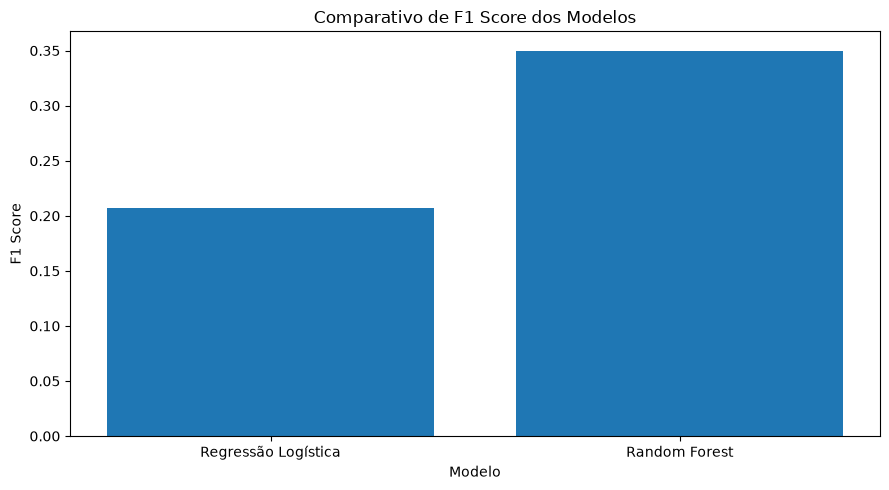

In [23]:
#Gráfico comparativo de F1 Score

plt.figure(figsize=(9, 5))

plt.bar(
    comparativo_modelos["modelo"],
    comparativo_modelos["f1_score"]
)

plt.title("Comparativo de F1 Score dos Modelos")
plt.xlabel("Modelo")
plt.ylabel("F1 Score")

plt.tight_layout()
plt.savefig(
    CAMINHO_GRAFICOS / "comparativo_f1_score_modelos.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

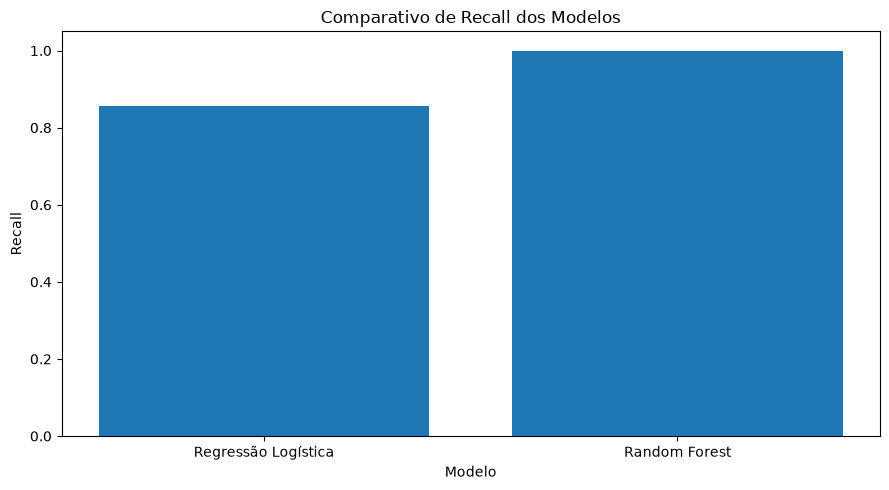

In [24]:
#Gráfico comparativo de Recall

plt.figure(figsize=(9, 5))

plt.bar(
    comparativo_modelos["modelo"],
    comparativo_modelos["recall"]
)

plt.title("Comparativo de Recall dos Modelos")
plt.xlabel("Modelo")
plt.ylabel("Recall")

plt.tight_layout()
plt.savefig(
    CAMINHO_GRAFICOS / "comparativo_recall_modelos.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [25]:
#Obter importância das variáveis

importancia_variaveis = obter_importancia_variaveis_random_forest(
    modelo_random_forest
)

importancia_variaveis.head(15)

,variavel,importancia
3,categoricas__canal_Robô,0.312387
2,categoricas__canal_Humano,0.288683
14,numericas__score_prioridade,0.215449
11,categoricas__status_antes_Disponível,0.037813
1,categoricas__cenario_Sem Orquestrador,0.032954
13,categoricas__status_antes_Fila Prioritária,0.030995
0,categoricas__cenario_Com Orquestrador,0.026669
4,categoricas__cultura_Cana,0.015529
6,categoricas__cultura_Soja,0.009209
5,categoricas__cultura_Milho,0.008356


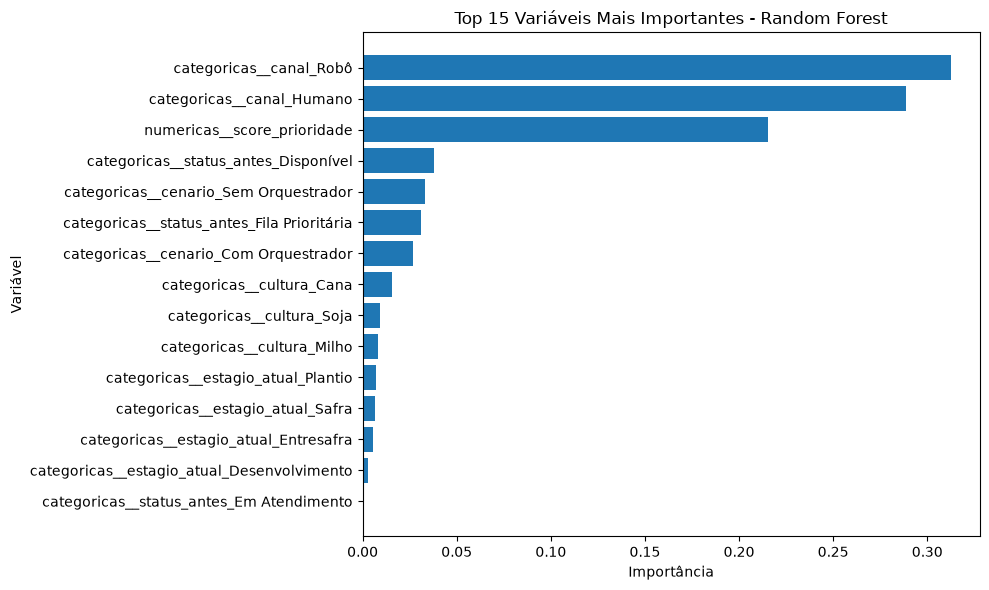

In [26]:
#Gráfico de importância das variáveis

top_importancias = importancia_variaveis.head(15).sort_values(
    by="importancia",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_importancias["variavel"],
    top_importancias["importancia"]
)

plt.title("Top 15 Variáveis Mais Importantes - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")

plt.tight_layout()
plt.savefig(
    CAMINHO_GRAFICOS / "importancia_variaveis_random_forest.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [27]:
#Previsão de probabilidade de venda

amostra_previsao = x_teste.copy()

amostra_previsao["converteu_real"] = y_teste.values

amostra_previsao["probabilidade_venda"] = (
    modelo_random_forest
    .predict_proba(x_teste)[:, 1]
)

amostra_previsao["previsao_modelo"] = (
    modelo_random_forest
    .predict(x_teste)
)

amostra_previsao = amostra_previsao.sort_values(
    by="probabilidade_venda",
    ascending=False
)

amostra_previsao.head(20)

,cenario,canal,cultura,estagio_atual,status_antes,score_prioridade,converteu_real,probabilidade_venda,previsao_modelo
495,Com Orquestrador,Humano,Cana,Plantio,Fila Prioritária,0.00,1,0.912541,1
326,Com Orquestrador,Humano,Cana,Plantio,Fila Prioritária,0.00,1,0.912541,1
329,Com Orquestrador,Humano,Cana,Plantio,Fila Prioritária,0.00,1,0.912541,1
211,Sem Orquestrador,Humano,Cana,Safra,Disponível,98.01,0,0.845897,1
138,Sem Orquestrador,Humano,Cana,Safra,Disponível,96.53,0,0.845897,1
119,Sem Orquestrador,Humano,Soja,Safra,Disponível,103.95,1,0.789189,1
276,Sem Orquestrador,Humano,Cana,Desenvolvimento,Disponível,95.70,0,0.776303,1
217,Sem Orquestrador,Humano,Cana,Desenvolvimento,Disponível,88.00,0,0.775627,1
250,Sem Orquestrador,Humano,Cana,Desenvolvimento,Disponível,77.00,0,0.775340,1
287,Sem Orquestrador,Humano,Cana,Plantio,Disponível,150.15,0,0.775236,1


In [28]:
#Top oportunidades previstas

top_oportunidades_previstas = amostra_previsao.head(30)

top_oportunidades_previstas

,cenario,canal,cultura,estagio_atual,status_antes,score_prioridade,converteu_real,probabilidade_venda,previsao_modelo
495,Com Orquestrador,Humano,Cana,Plantio,Fila Prioritária,0.00,1,0.912541,1
326,Com Orquestrador,Humano,Cana,Plantio,Fila Prioritária,0.00,1,0.912541,1
329,Com Orquestrador,Humano,Cana,Plantio,Fila Prioritária,0.00,1,0.912541,1
211,Sem Orquestrador,Humano,Cana,Safra,Disponível,98.01,0,0.845897,1
138,Sem Orquestrador,Humano,Cana,Safra,Disponível,96.53,0,0.845897,1
119,Sem Orquestrador,Humano,Soja,Safra,Disponível,103.95,1,0.789189,1
276,Sem Orquestrador,Humano,Cana,Desenvolvimento,Disponível,95.70,0,0.776303,1
217,Sem Orquestrador,Humano,Cana,Desenvolvimento,Disponível,88.00,0,0.775627,1
250,Sem Orquestrador,Humano,Cana,Desenvolvimento,Disponível,77.00,0,0.775340,1
287,Sem Orquestrador,Humano,Cana,Plantio,Disponível,150.15,0,0.775236,1


In [29]:
#Salvar comparativo de modelos

CAMINHO_COMPARATIVO_MODELOS = CAMINHO_OUTPUTS / "comparativo_modelos_ml.csv"

comparativo_modelos.to_csv(
    CAMINHO_COMPARATIVO_MODELOS,
    index=False,
    encoding="utf-8-sig"
)

print("Comparativo de modelos salvo em:", CAMINHO_COMPARATIVO_MODELOS)

Comparativo de modelos salvo em: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator\outputs\comparativo_modelos_ml.csv


In [30]:
#Salvar importância das variáveis

CAMINHO_IMPORTANCIA_VARIAVEIS = CAMINHO_OUTPUTS / "importancia_variaveis_random_forest.csv"

importancia_variaveis.to_csv(
    CAMINHO_IMPORTANCIA_VARIAVEIS,
    index=False,
    encoding="utf-8-sig"
)

print("Importância das variáveis salva em:", CAMINHO_IMPORTANCIA_VARIAVEIS)

Importância das variáveis salva em: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator\outputs\importancia_variaveis_random_forest.csv


In [31]:
#Salvar top oportunidades previstas

CAMINHO_TOP_OPORTUNIDADES = CAMINHO_OUTPUTS / "top_oportunidades_previstas.csv"

top_oportunidades_previstas.to_csv(
    CAMINHO_TOP_OPORTUNIDADES,
    index=False,
    encoding="utf-8-sig"
)

print("Top oportunidades previstas salvo em:", CAMINHO_TOP_OPORTUNIDADES)

Top oportunidades previstas salvo em: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator\outputs\top_oportunidades_previstas.csv


## Conclusão da Modelagem

Este notebook demonstrou a aplicação de Machine Learning sobre os dados simulados da operação comercial.

Foram treinados dois modelos:

- Regressão Logística;
- Random Forest.

O objetivo foi prever a chance de conversão de uma interação comercial com base em variáveis como canal, cultura, estágio agrícola, status anterior e score de prioridade.

Como a base é sintética e gerada por regras de negócio, os resultados devem ser interpretados como uma demonstração técnica de pipeline de modelagem, e não como um modelo produtivo real.

Mesmo assim, esta etapa demonstra um fluxo completo de Ciência de dados, incluindo preparação da base, treinamento, avaliação, comparação de modelos e interpretação de variáveis.